In [11]:
"""
variables x1, x2 y resultado son numericas, las variables x1 y x2 son variables que nos serviran para predecir el resultado, si es 0 o 1
"""

'\nvariables x1, x2 y resultado son numericas, las variables x1 y x2 son variables que nos serviran para predecir el resultado, si es 0 o 1\n'

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [13]:
#Importacion del csv
df_games = pd.read_csv('dataset_partida.csv')
df_games.head()

,x1,x2,resultado
0,-0.125245,0.552601,1
1,0.685084,-0.323315,1
2,0.769488,0.607225,0
3,0.428378,0.157977,1
4,0.075636,0.873185,0


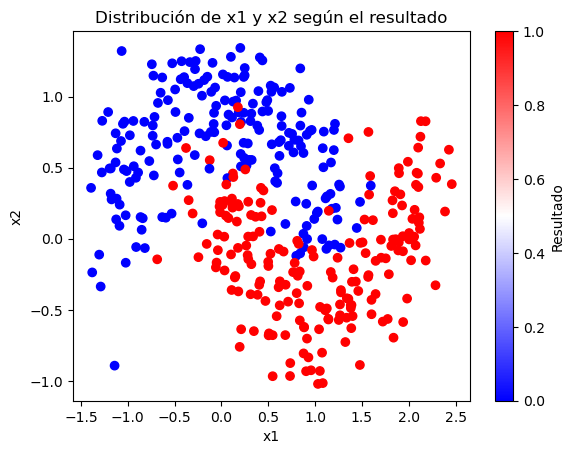

'Podemos ver que cuanto mayor es el valor de x1, el resultado tiende a ser 1,\nmientras que cuanto mayor es el valor de x2, el resultado tiende a ser 0'

In [14]:
#Comparación de datos de x1 y x2
plt.scatter(df_games['x1'], df_games['x2'], c=df_games['resultado'], cmap='bwr')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Distribución de x1 y x2 según el resultado')
plt.colorbar(label='Resultado')
plt.show()

"""Podemos ver que cuanto mayor es el valor de x1, el resultado tiende a ser 1,
mientras que cuanto mayor es el valor de x2, el resultado tiende a ser 0"""

In [15]:
#Correlacion de las variables con el resultado
df_games.corr(numeric_only=True)['resultado'].sort_values(ascending=False)[1:]

x1    0.536988
x2   -0.674709
Name: resultado, dtype: float64

In [16]:
#Entrenamiento y formalización de los datos
X = df_games.drop(['resultado'],axis=1)
y = df_games['resultado'].to_frame()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
#Entrenamiento con kernel lineal
svm_lineal = SVC(kernel="linear", C=1.0, random_state=42)
svm_lineal.fit(X_train_scaled, y_train)

/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(kernel='linear', random_state=42)

In [24]:
#Muestra de datos del entrenamiento con kernel lineal
pred_lineal = svm_lineal.predict(X_test_scaled)

print("=== SVM LINEAL ===")
print("Accuracy:", accuracy_score(y_test, pred_lineal)) 
print(confusion_matrix(y_test, pred_lineal))
print(classification_report(y_test, pred_lineal))

=== SVM LINEAL ===
Accuracy: 0.92
[[46  4]
 [ 4 46]]
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        50
           1       0.92      0.92      0.92        50

    accuracy                           0.92       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.92      0.92      0.92       100



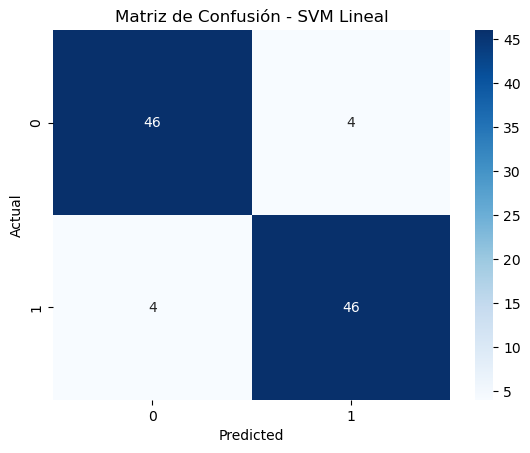

In [28]:
#Pintar matriz de confusion
import seaborn as sns
cm = confusion_matrix(y_test, pred_lineal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión - SVM Lineal')
plt.show()

In [ ]:
#Entrenamiento con diferentes kernels para sacar la mejor configuración
valores_C = [0.1, 1, 4, 7, 10]
valores_degree = [2, 3, 4, 5, 6]

mejor_acc = 0
mejor_config = None

for C in valores_C:
    for degree in valores_degree:
        print(f"\nProbando C={C} | degree={degree}")

        svm_poly = SVC(kernel="poly", degree=degree, coef0=1, C=C)
        svm_poly.fit(X_train_scaled, y_train)

        pred = svm_poly.predict(X_test_scaled)
        acc = accuracy_score(y_test, pred)

        print(f"Accuracy: {acc:.4f}")

        if acc > mejor_acc:
            mejor_acc = acc
            mejor_config = (C, degree)

pred_rbf = svm_poly.predict(X_test_scaled)

print(f"Mejor Accuracy: {mejor_acc:.4f}")
print(f"Mejor C y degree: C={mejor_config[0]}, degree={mejor_config[1]}")
print(confusion_matrix(y_test, pred_rbf))
print(classification_report(y_test, pred_rbf))


Probando C=0.1 | degree=2
Accuracy: 0.9200

Probando C=0.1 | degree=3
Accuracy: 0.9600

Probando C=0.1 | degree=4
Accuracy: 0.9700

Probando C=0.1 | degree=5
Accuracy: 0.9400

Probando C=0.1 | degree=6
Accuracy: 0.9200

Probando C=1 | degree=2
Accuracy: 0.9100

Probando C=1 | degree=3
Accuracy: 0.9400

Probando C=1 | degree=4
Accuracy: 0.9300

Probando C=1 | degree=5
Accuracy: 0.9200

Probando C=1 | degree=6
Accuracy: 0.9200

Probando C=4 | degree=2
Accuracy: 0.9200

Probando C=4 | degree=3
Accuracy: 0.9300

Probando C=4 | degree=4
Accuracy: 0.9200

Probando C=4 | degree=5
Accuracy: 0.9200

Probando C=4 | degree=6
Accuracy: 0.9200

Probando C=7 | degree=2
Accuracy: 0.9200

Probando C=7 | degree=3
Accuracy: 0.9200

Probando C=7 | degree=4
Accuracy: 0.9200

Probando C=7 | degree=5
Accuracy: 0.9200

Probando C=7 | degree=6
Accuracy: 0.9200

Probando C=10 | degree=2
Accuracy: 0.9200

Probando C=10 | degree=3
Accuracy: 0.9200

Probando C=10 | degree=4
Accuracy: 0.9200

Probando C=10 | degr

/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Ple

In [ ]:
#Mejor configuración encontrada
svm_poly = SVC(kernel="poly", degree=4, coef0=1, C=0.1)
svm_poly.fit(X_train_scaled, y_train)
pred_poly = svm_poly.predict(X_test_scaled)

print("=== SVM POLINOMIAL ===")
print("Accuracy:", accuracy_score(y_test, pred_poly))
print(confusion_matrix(y_test, pred_poly))
print(classification_report(y_test, pred_poly))

=== SVM POLINOMIAL ===
Accuracy: 0.97
[[48  2]
 [ 1 49]]
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        50
           1       0.96      0.98      0.97        50

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


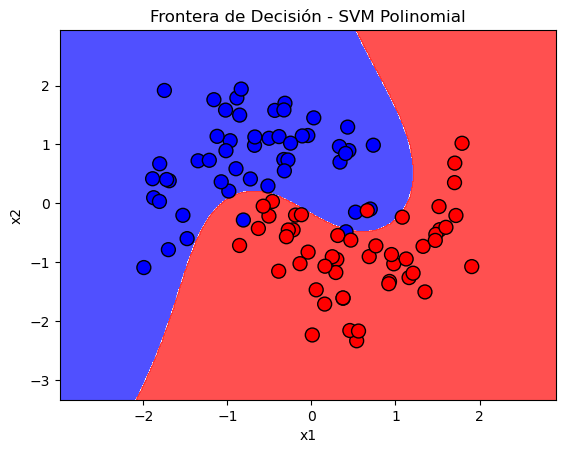

In [34]:
#dibujar la frontera de decision del modelo polinomial
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), edgecolors='k', marker='o', s=100, cmap='bwr')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('Frontera de Decisión - SVM Polinomial')
    plt.show()

plot_decision_boundary(svm_poly, X_test_scaled, y_test.values)